In [2]:
import sys
import os
sys.path.insert(0, '..')

In [38]:
from src.data.processor import MarketDataProcessor
from src.data.db_client import DatabaseClient
from src.models.optimizer import PortfolioOptimizer
from src.models.risk import RiskMetrics

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

In [39]:
# Cell 2: Load Data
symbols = ['AAPL', 'GOOGL', 'MSFT', 'META', 'NVDA','CAT', 'BA','SPY']
db = DatabaseClient()
processor = MarketDataProcessor(db)
out = processor.run(tickers = symbols)
prices = out['prices']
returns = out['returns']

In [40]:
# Cell 3: Run Optimizations
opt= PortfolioOptimizer()

In [41]:
# Check if prices DataFrame is still valid
print(f"Shape: {prices.shape}")
print(f"Columns: {prices.columns.tolist()}")
print(f"Date range: {prices.index[0]} to {prices.index[-1]}")
print(f"NaN count:\n{prices.isnull().sum()}")
print(f"\nFirst few rows:\n{prices.head()}")



Shape: (500, 8)
Columns: ['AAPL', 'BA', 'CAT', 'GOOGL', 'META', 'MSFT', 'NVDA', 'SPY']
Date range: 2024-02-12 05:00:00+00:00 to 2026-02-09 05:00:00+00:00
NaN count:
ticker
AAPL     0
BA       0
CAT      0
GOOGL    0
META     0
MSFT     0
NVDA     0
SPY      0
dtype: int64

First few rows:
ticker                       AAPL      BA     CAT   GOOGL    META    MSFT  \
timestamp                                                                   
2024-02-12 05:00:00+00:00  187.15  209.33  321.63  147.53  468.90  415.26   
2024-02-13 05:00:00+00:00  185.04  204.46  312.84  145.14  460.12  406.32   
2024-02-14 05:00:00+00:00  184.15  203.38  316.71  145.94  473.28  409.49   
2024-02-15 05:00:00+00:00  183.86  205.33  323.07  142.77  484.03  406.56   
2024-02-16 05:00:00+00:00  182.31  203.89  321.91  140.52  473.32  404.06   

ticker                       NVDA     SPY  
timestamp                                  
2024-02-12 05:00:00+00:00  72.248  500.98  
2024-02-13 05:00:00+00:00  72.128  494

In [43]:
max_sharpe_result = opt.optimize_max_sharpe(prices)

In [44]:
print(f"Max Sharpe Strategy: {max_sharpe_result['sharpe_ratio']:.2f}")

Max Sharpe Strategy: 1.56


In [45]:
# Min Volatility
min_vol_result = opt.optimize_min_volatility(prices)
print(f"Min Vol Strategy: {min_vol_result['annual_volatility']:.2%}")

Min Vol Strategy: 18.97%


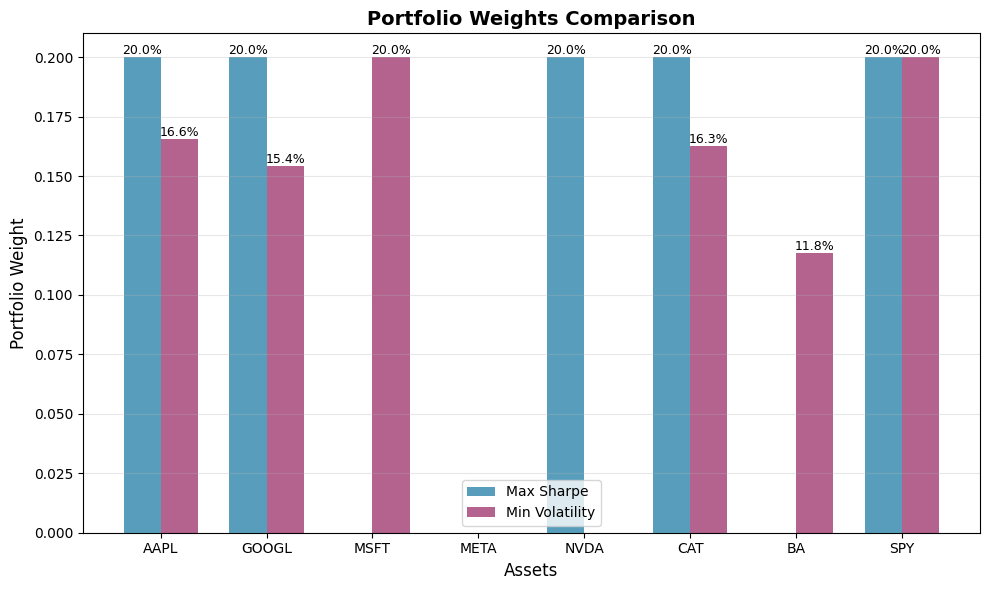

In [46]:
# Ensure weights are aligned with symbols
symbols = ['AAPL', 'GOOGL', 'MSFT', 'META', 'NVDA','CAT', 'BA','SPY']

# Extract weights in the correct order
max_sharpe_weights = [max_sharpe_result['weights'].get(symbol, 0) for symbol in symbols]
min_vol_weights = [min_vol_result['weights'].get(symbol, 0) for symbol in symbols]

# Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(symbols))
width = 0.35

bars1 = ax.bar(x - width/2, max_sharpe_weights, width, label='Max Sharpe', alpha=0.8, color='#2E86AB')
bars2 = ax.bar(x + width/2, min_vol_weights, width, label='Min Volatility', alpha=0.8, color='#A23B72')

ax.set_xlabel('Assets', fontsize=12)
ax.set_ylabel('Portfolio Weight', fontsize=12)
ax.set_title('Portfolio Weights Comparison', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(symbols)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0.01:  # Only show if weight > 1%
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.1%}',
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


In [47]:
metrics_df = pd.DataFrame({
    'Max Sharpe': [
        max_sharpe_result['sharpe_ratio'],
        max_sharpe_result['expected_annual_return'],
        max_sharpe_result['annual_volatility'],
        max_sharpe_result['expected_annual_return']
    ],
    'Min Volatility': [
        min_vol_result['sharpe_ratio'],
        min_vol_result['expected_annual_return'],
        min_vol_result['annual_volatility'],
        min_vol_result['expected_annual_return']
    ]
}, index=['Sharpe Ratio', 'Expected Annual Return', 'Annual Volatility','Expected Annual Return'])

metrics_df


,Max Sharpe,Min Volatility
Sharpe Ratio,1.556585,1.044424
Expected Annual Return,0.407237,0.241126
Annual Volatility,0.233997,0.189699
Expected Annual Return,0.407237,0.241126


In [48]:
risk_max_sharpe = RiskMetrics(returns, max_sharpe_result['weights'])
risk_min_vol = RiskMetrics(returns, min_vol_result['weights'])

In [49]:
risk_comparison = pd.DataFrame({
    'Max Sharpe': [
        risk_max_sharpe.portfolio_volatility(),
        risk_max_sharpe.value_at_risk(0.95),
        risk_max_sharpe.conditional_var(0.95),
        risk_max_sharpe.maximum_drawdown()
    ],
    'Min Volatility': [
        risk_min_vol.portfolio_volatility(),
        risk_min_vol.value_at_risk(0.95),
        risk_min_vol.conditional_var(0.95),
        risk_min_vol.maximum_drawdown()
    ]
}, index=['Volatility', 'VaR (95%)', 'CVaR (95%)', 'Max Drawdown'])

risk_comparison

,Max Sharpe,Min Volatility
Volatility,0.233998,0.189701
VaR (95%),-0.022467,-0.016673
CVaR (95%),-0.033736,-0.027324
Max Drawdown,-0.266709,-0.236760
